# ARTI 403 Image Processing
## Lab 4: Intensity Transformations and Filtering in the Spatial Domain

**Name:** Mohammed Saeed Alamodi | **ID:** 2240009007

Covers the Lab 4 procedural steps (thresholding and histogram processing) plus the three
assessment tasks (contrast stretching with new percentiles, histogram equalization and
histogram matching).

Note: `cv2.imshow()` / `cv2.waitKey()` don't work inside a notebook, so matplotlib is used instead
to display the images.

### Setup
Make an `images` folder and save the images used in this lab. The manual uses `Parrot.png` for
thresholding but it wasn't given with the lab files, so I used the coffee image from skimage
(converted to grayscale) instead. The moon, rocket and Chelsea images are also saved so the
folder has every image used.

In [1]:
import os
import numpy as np
from PIL import Image
from skimage import data, color, img_as_ubyte

os.makedirs('images', exist_ok=True)

if not os.path.exists('images/coffee.png'):
    Image.fromarray(img_as_ubyte(color.rgb2gray(data.coffee()))).save('images/coffee.png')

if not os.path.exists('images/moon.png'):
    Image.fromarray(data.moon()).save('images/moon.png')

if not os.path.exists('images/rocket.png'):
    Image.fromarray(data.rocket()).save('images/rocket.png')

if not os.path.exists('images/chelsea.png'):
    Image.fromarray(data.chelsea()).save('images/chelsea.png')

print('Images ready:', sorted(os.listdir('images')))

Images ready: ['chelsea.png', 'coffee.png', 'moon.png', 'rocket.png']


## Procedural Steps
### Task #1: Thresholding
**Step #1: Apply thresholding with a fixed threshold on an image**

Each pixel above the threshold becomes white (255) and everything else becomes black (0).

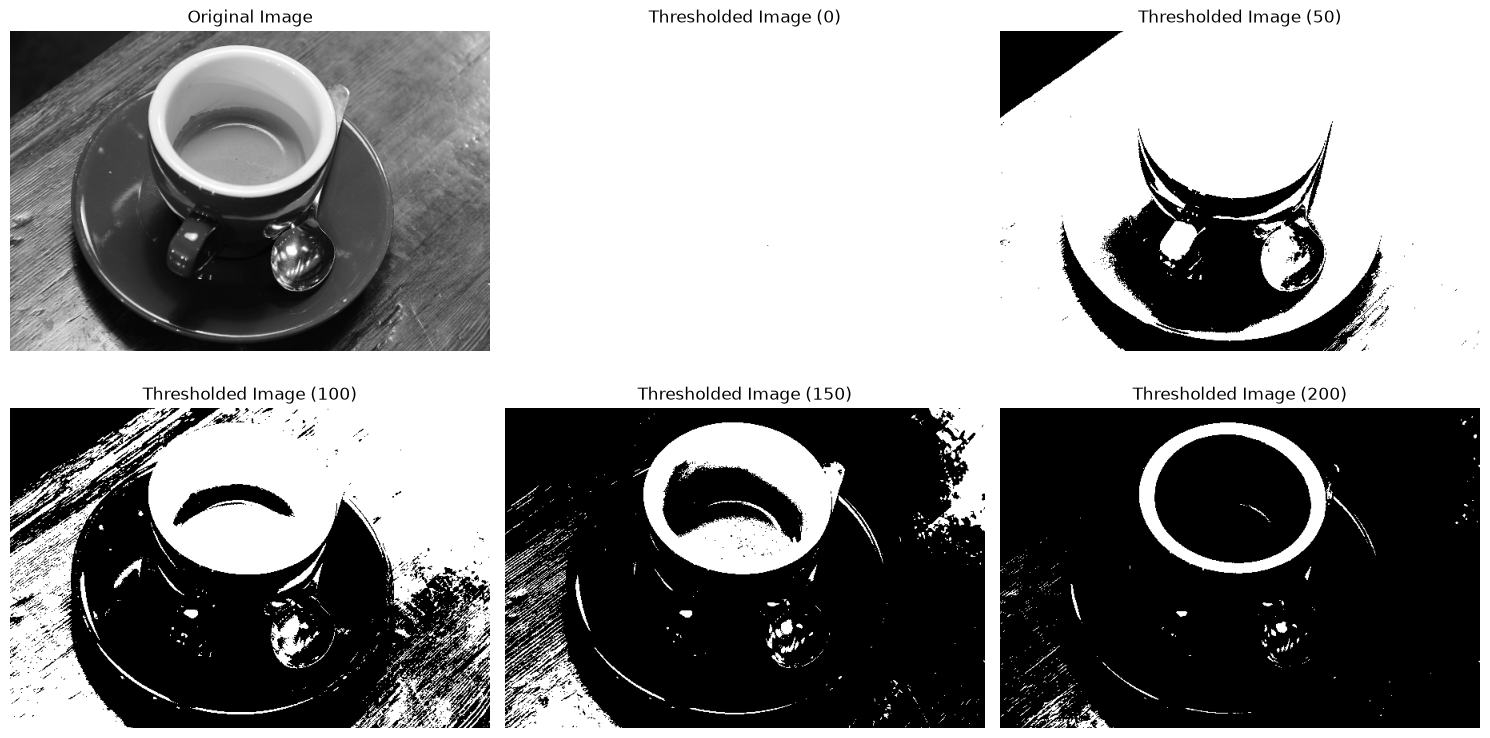

In [2]:
import cv2
import matplotlib.pyplot as plt

# Load the image in grayscale
img = cv2.imread('images/coffee.png', cv2.IMREAD_GRAYSCALE)

# Set the threshold values
threshold_values = [0, 50, 100, 150, 200]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

# Display the original image
axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original Image')

# Apply thresholding with different threshold values
for i, threshold_value in enumerate(threshold_values):
    ret, thresh = cv2.threshold(img, threshold_value, 255, cv2.THRESH_BINARY)
    axes[i + 1].imshow(thresh, cmap='gray')
    axes[i + 1].set_title(f'Thresholded Image ({threshold_value})')

for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

**Observation:** With a threshold of 0 almost the whole image turns white since nearly every
pixel is above 0. As the threshold goes up, more pixels fall below it and turn black. At 150 the
inside of the cup stands out from the dark saucer, and at 200 only the brightest part (the white
rim of the cup) and a few highlights on the spoon are left. For this image something around 150
works best to pick out the cup.

### Task #2: Histogram Processing
**Step #1: Load necessary libraries**

In [3]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from skimage import data, img_as_float
from skimage import exposure

**Step #2: Load moon image**

In [4]:
img = data.moon()
print('Shape:', img.shape, '| dtype:', img.dtype)
print('Min:', img.min(), '| Max:', img.max())

Shape: (512, 512) | dtype: uint8
Min: 0 | Max: 255


**Step #3: Rescale intensity values to include all the intensities that fall within the 2nd and 98th percentiles**

In [5]:
# Contrast stretching
p2, p98 = np.percentile(img, (2, 98))
img_rescale = exposure.rescale_intensity(img, in_range=(p2, p98))
print('2nd percentile:', p2, '| 98th percentile:', p98)

2nd percentile: 78.0 | 98th percentile: 129.0


**Step #4: Display the image with its histogram of (Step #2) and (Step #3)**

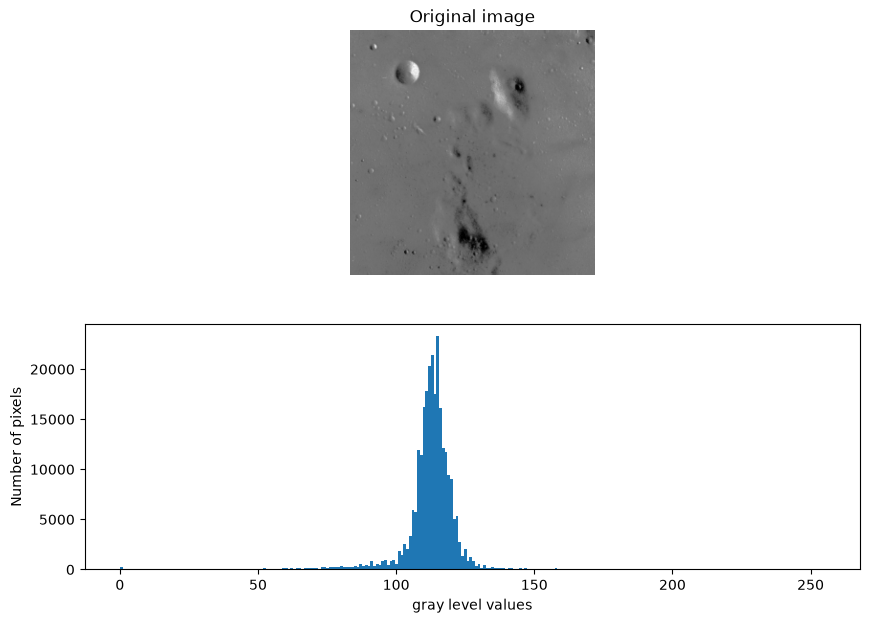

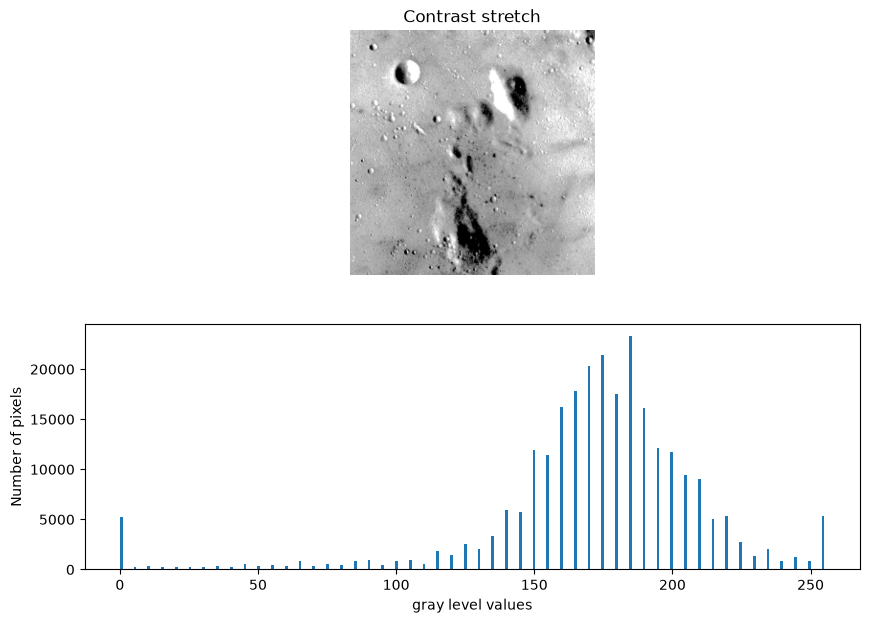

In [6]:
fig = plt.figure(figsize=(10, 7))
fig.add_subplot(2, 1, 1)
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.title('Original image')
fig.add_subplot(2, 1, 2)
plt.hist(img.flat, bins=256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

fig = plt.figure(figsize=(10, 7))
fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale, cmap='gray')
plt.axis('off')
plt.title('Contrast stretch')
fig.add_subplot(2, 1, 2)
plt.hist(img_rescale.flat, bins=256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

## Practical Session Tasks (Assessment)

### Task #1: Contrast stretching using the 3rd and 80th percentiles
Using the same moon image, rescale the intensity values to include all the intensities that fall
within the 3rd and 80th percentiles, and plot the histogram.

3rd percentile: 87.0 | 80th percentile: 118.0


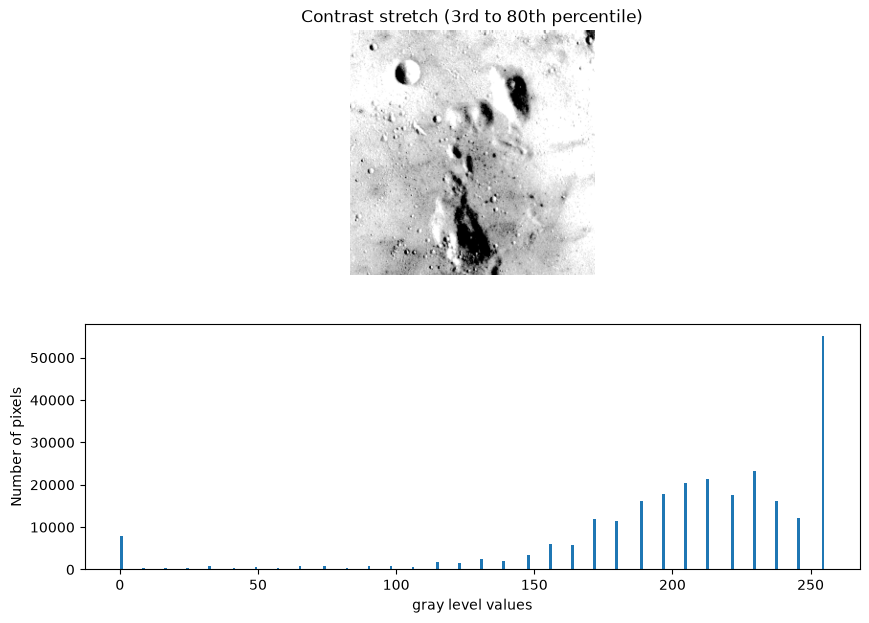

In [7]:
p3, p80 = np.percentile(img, (3, 80))
img_rescale_3_80 = exposure.rescale_intensity(img, in_range=(p3, p80))
print('3rd percentile:', p3, '| 80th percentile:', p80)

fig = plt.figure(figsize=(10, 7))
fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale_3_80, cmap='gray')
plt.axis('off')
plt.title('Contrast stretch (3rd to 80th percentile)')
fig.add_subplot(2, 1, 2)
plt.hist(img_rescale_3_80.flat, bins=256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

**Observation:** The moon image only uses a narrow range of gray levels (3rd percentile = 87,
80th percentile = 118), so stretching that small range to 0..255 makes the histogram look like
separate bars with gaps between them. Since the upper limit is the 80th percentile instead of the
98th, every pixel brighter than 118 gets pushed to 255, which is the tall spike on the right. The
result is a much brighter image where the light areas are washed out, but the dark craters and
shadows stand out more than in the 2nd to 98th version.

### Task #2: Histogram equalization
Using the same moon image and `exposure.equalize_hist`, display the image and its histogram after
flattening the histogram.

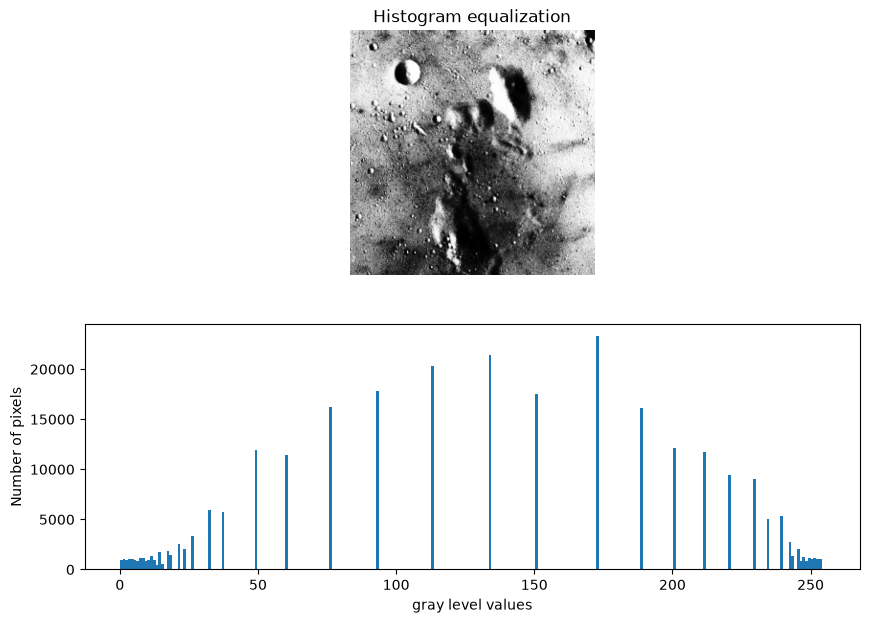

In [8]:
# equalize_hist returns floats in [0, 1], so scale back to 0..255 for the histogram
img_eq = exposure.equalize_hist(img)
img_eq = (img_eq * 255).astype(np.uint8)

fig = plt.figure(figsize=(10, 7))
fig.add_subplot(2, 1, 1)
plt.imshow(img_eq, cmap='gray')
plt.axis('off')
plt.title('Histogram equalization')
fig.add_subplot(2, 1, 2)
plt.hist(img_eq.flat, bins=256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

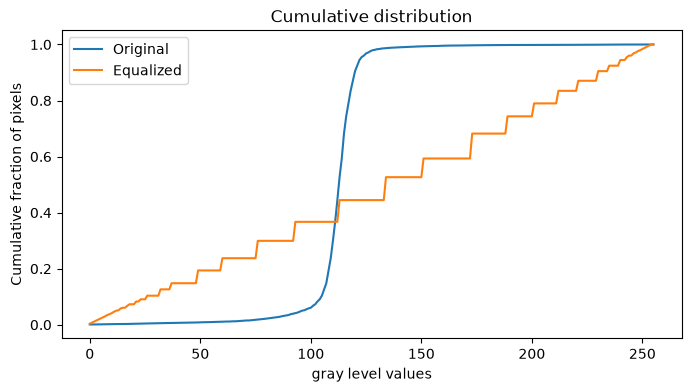

In [9]:
# Cumulative distribution before and after equalization
cdf_orig, bins_orig = exposure.cumulative_distribution(img)
cdf_eq, bins_eq = exposure.cumulative_distribution(img_eq)

plt.figure(figsize=(8, 4))
plt.plot(bins_orig, cdf_orig, label='Original')
plt.plot(bins_eq, cdf_eq, label='Equalized')
plt.xlabel('gray level values')
plt.ylabel('Cumulative fraction of pixels')
plt.title('Cumulative distribution')
plt.legend()
plt.show()

**Observation:** In the original image most pixels are packed into a narrow range of gray
levels. After equalization they're spread across the whole 0 to 255 range, so the histogram is
much flatter and the cumulative distribution is close to a straight line. The image has a lot more
contrast and the surface texture is easier to see, but some noise in the flat regions also gets
amplified.

### Task #3: Histogram matching
Use the rocket image as the reference and the Chelsea image as the source, then match the
histogram of Chelsea to the rocket. Both are color images, so the matching is done on each
channel separately (`channel_axis=-1`).

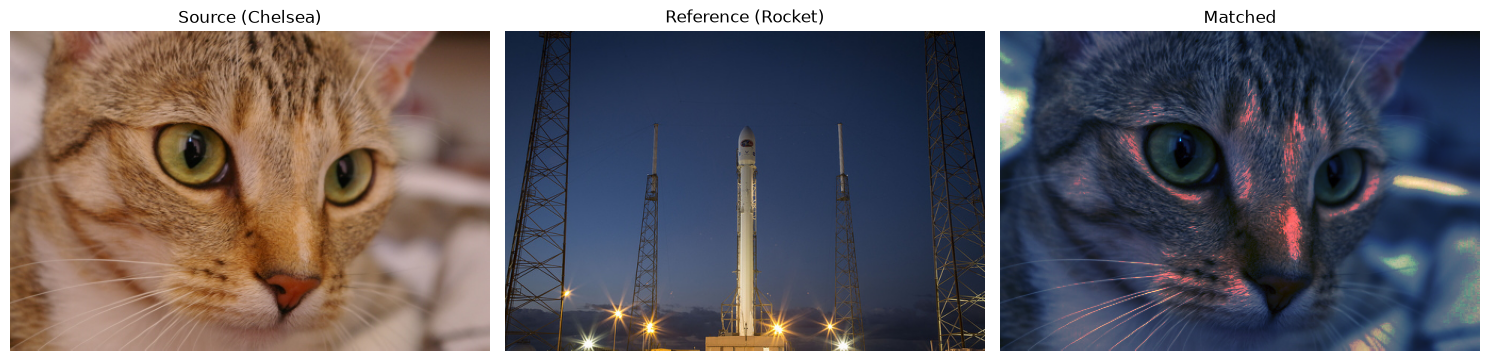

In [10]:
reference = data.rocket()
image = data.chelsea()

matched = exposure.match_histograms(image, reference, channel_axis=-1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(image); axes[0].set_title('Source (Chelsea)')
axes[1].imshow(reference); axes[1].set_title('Reference (Rocket)')
axes[2].imshow(matched.astype(np.uint8)); axes[2].set_title('Matched')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

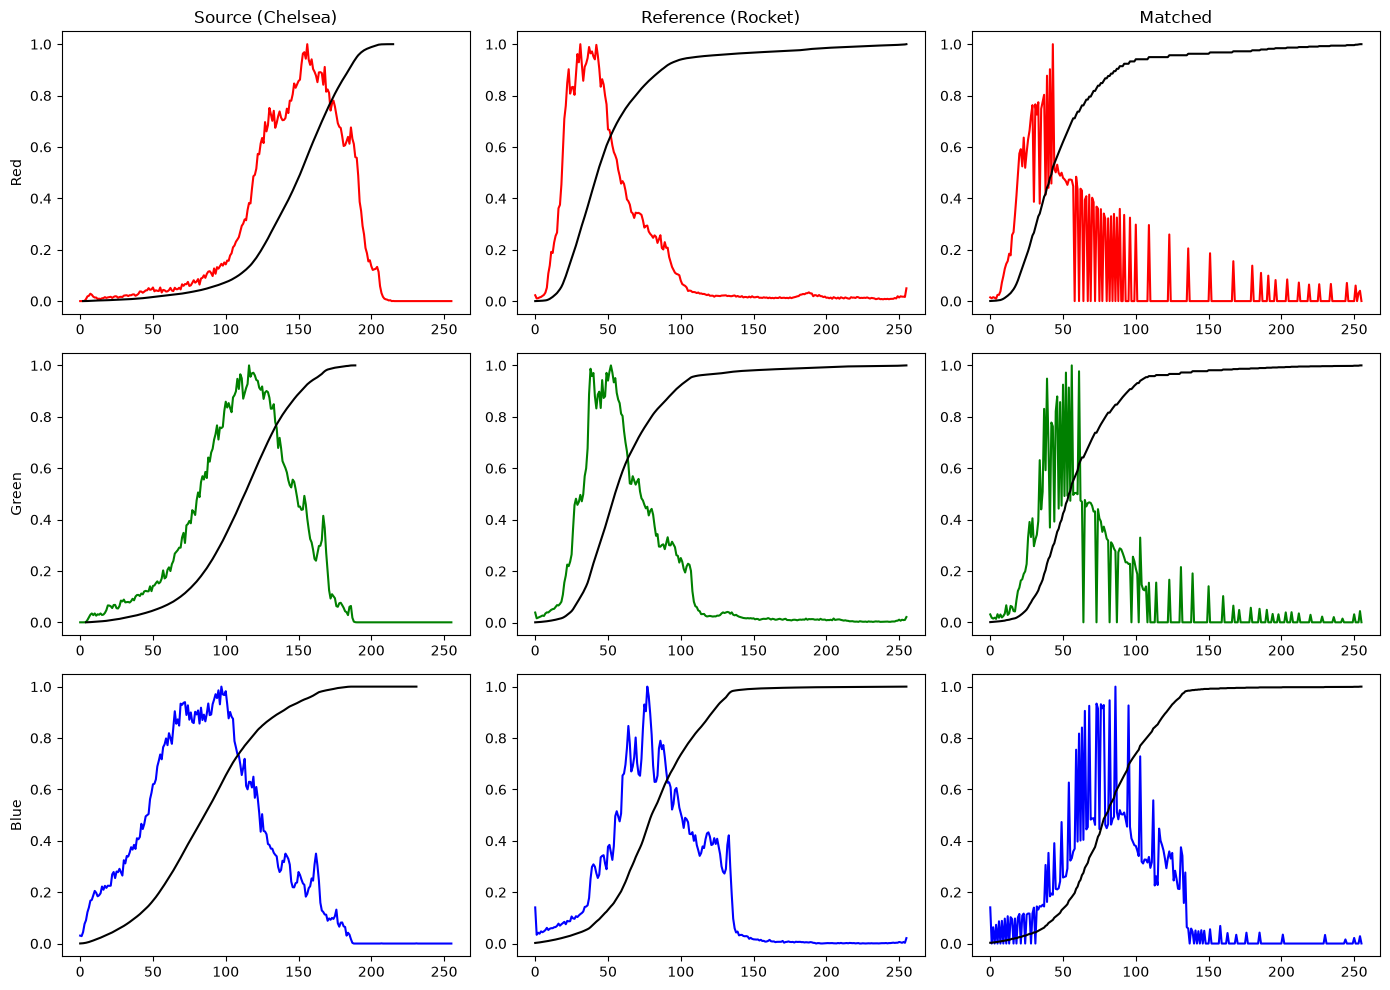

In [11]:
# Histogram and cumulative histogram of each channel for the three images
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
channel_names = ['Red', 'Green', 'Blue']

for i, img_ in enumerate((image, reference, matched)):
    for c, c_color in enumerate(('red', 'green', 'blue')):
        hist, bins = exposure.histogram(img_[..., c], source_range='dtype')
        axes[c, i].plot(bins, hist / hist.max(), color=c_color)
        cdf, bins = exposure.cumulative_distribution(img_[..., c])
        axes[c, i].plot(bins, cdf, color='black')
        axes[c, 0].set_ylabel(channel_names[c])

axes[0, 0].set_title('Source (Chelsea)')
axes[0, 1].set_title('Reference (Rocket)')
axes[0, 2].set_title('Matched')

plt.tight_layout()
plt.show()

**Observation:** The matched image keeps the content of the Chelsea image (the cat) but its
colors now follow the rocket image, so it looks darker and mostly blue like the night sky, with
some red spots where the original fur was brightest. In the histogram plots, the black cumulative
curves of the matched image look almost the same as the reference for all three channels, which
shows the matching worked.